## Driver Comparison — 1st vs Last during Monza GP Qualifying 2023

The goal of this analysis is to compare the fastest lap of 
Carlos Sainz (1st) and Lance Stroll (last) during the 
2023 Monza Grand Prix Qualifying, to understand their 
driving techniques and identify where time is gained 
and lost on the circuit.

We will use multi-channel overlay, time delta, G_combined 
and math channels such as Throttle & Corner Speed Analysis.

⚠️ Note: Sainz used Soft tyres while Stroll used Hard tyres. 
This significantly affects grip levels, corner speed, and 
braking performance, meaning part of the observed gap 
cannot be attributed solely to driving style differences.

In [72]:
import fastf1 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

session = fastf1.get_session(2023, 'Monza', 'Q')
session.load()


core           INFO 	Loading data for Italian Grand Prix - Qualifying [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['55', '1', '16', '63', '11', '23', '81', '44', '4', '14', '22', '40', '27', '77', '2', '24', '10', '31', '20', '18']


In [73]:
tel_SAI = session.laps.pick_drivers('SAI').pick_fastest().get_telemetry()
tel_STR = session.laps.pick_drivers('STR').pick_fastest().get_telemetry()


In [74]:
def euclidean_distance(x1, y1, x2, y2):
    return ((x2 - x1) ** 2 + (y2 - y1) ** 2) ** 0.5

def triangle_area(x1, y1, x2, y2, x3, y3):
    
    a = euclidean_distance(x1, y1, x2, y2)
    b = euclidean_distance(x2, y2, x3, y3)
    c = euclidean_distance(x3, y3, x1, y1)

    
    s = (a + b + c) / 2

    
    area = (s * (s - a) * (s - b) * (s - c)) ** 0.5
    return area


def radius(x1, y1, x2, y2, x3, y3):
    area = triangle_area(x1, y1, x2, y2, x3, y3)
    a = euclidean_distance(x1, y1, x2, y2)
    b = euclidean_distance(x2, y2, x3, y3)
    c = euclidean_distance(x3, y3, x1, y1)

    if area == 0:
        return float('inf')  

    radius = (a * b * c) / (4 * area)
    return radius



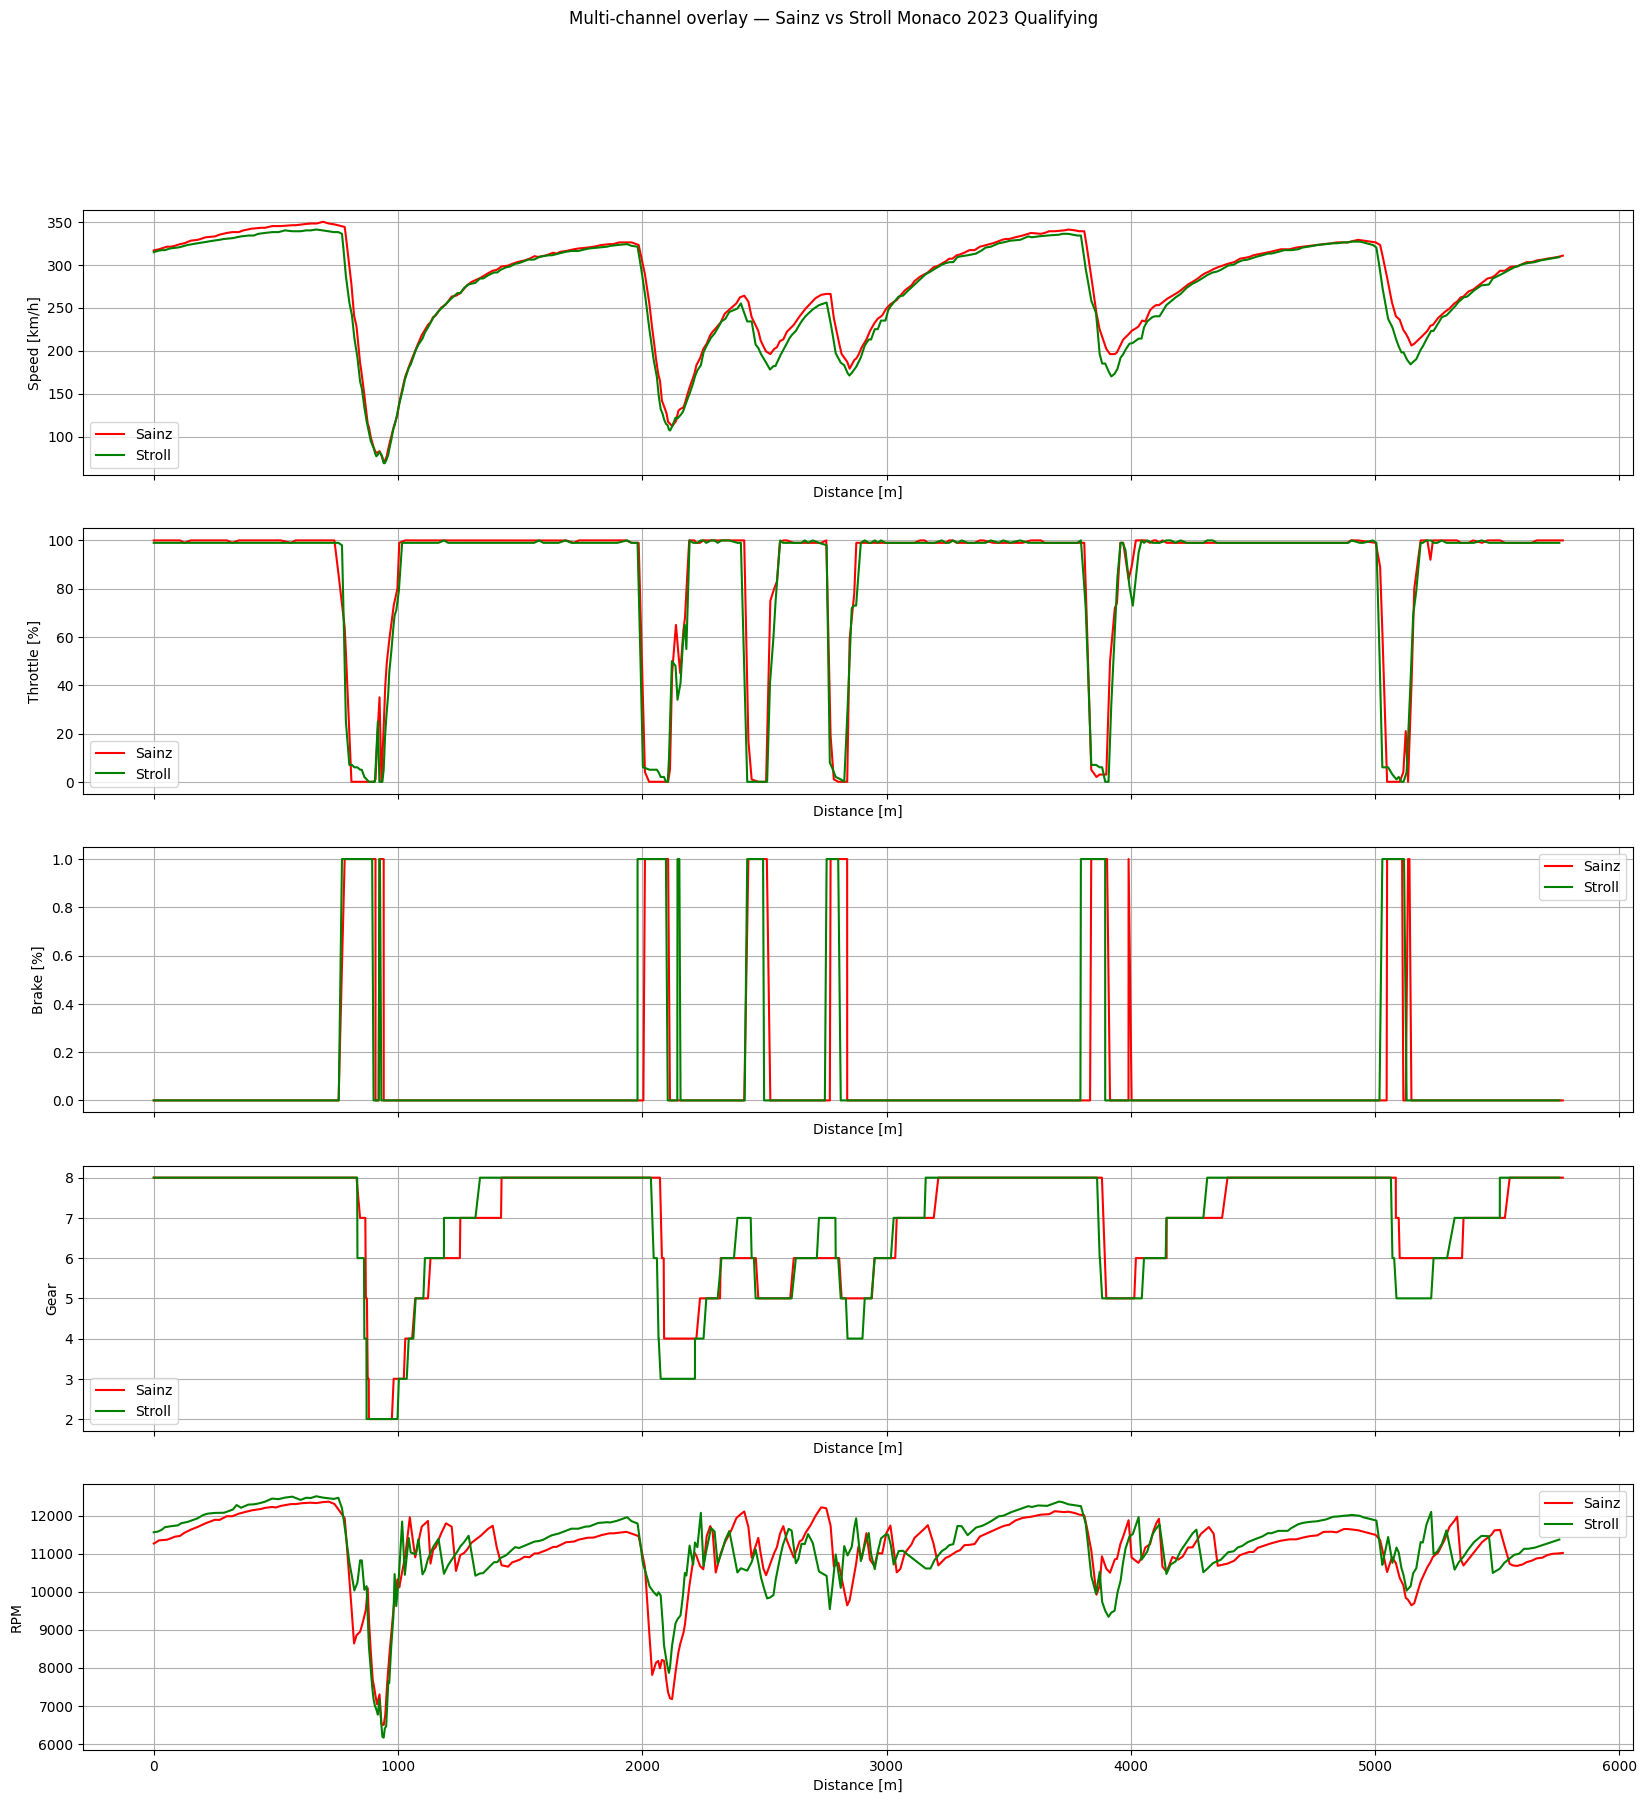

In [75]:
fig, axs = plt.subplots(5, 1, sharex=True, figsize=(20, 20))

axs[0].plot(tel_SAI['Distance'], tel_SAI['Speed'], label='Sainz', color='red')
axs[0].plot(tel_STR['Distance'], tel_STR['Speed'], label='Stroll', color='green')
axs[0].set_ylabel('Speed [km/h]')
axs[0].set_xlabel('Distance [m]')
axs[0].legend()
axs[0].grid()

axs[1].plot(tel_SAI['Distance'], tel_SAI['Throttle'], label='Sainz', color='red')
axs[1].plot(tel_STR['Distance'], tel_STR['Throttle'], label='Stroll', color='green')
axs[1].set_ylabel('Throttle [%]')
axs[1].set_xlabel('Distance [m]')
axs[1].legend()
axs[1].grid()

axs[2].plot(tel_SAI['Distance'], tel_SAI['Brake'], label='Sainz', color='red')
axs[2].plot(tel_STR['Distance'], tel_STR['Brake'], label='Stroll', color='green')
axs[2].set_ylabel('Brake [%]')  
axs[2].set_xlabel('Distance [m]')
axs[2].legend()
axs[2].grid()

axs[3].plot(tel_SAI['Distance'], tel_SAI['nGear'], label='Sainz', color='red')
axs[3].plot(tel_STR['Distance'], tel_STR['nGear'], label='Stroll', color='green')
axs[3].set_ylabel('Gear')
axs[3].set_xlabel('Distance [m]')
axs[3].legend()
axs[3].grid()

axs[4].plot(tel_SAI['Distance'], tel_SAI['RPM'], label='Sainz', color='red')
axs[4].plot(tel_STR['Distance'], tel_STR['RPM'], label='Stroll', color='green')
axs[4].set_ylabel('RPM')
axs[4].set_xlabel('Distance [m]')
axs[4].legend()
axs[4].grid()

plt.suptitle('Multi-channel overlay — Sainz vs Stroll Monaco 2023 Qualifying')
plt.show()



## Time difference

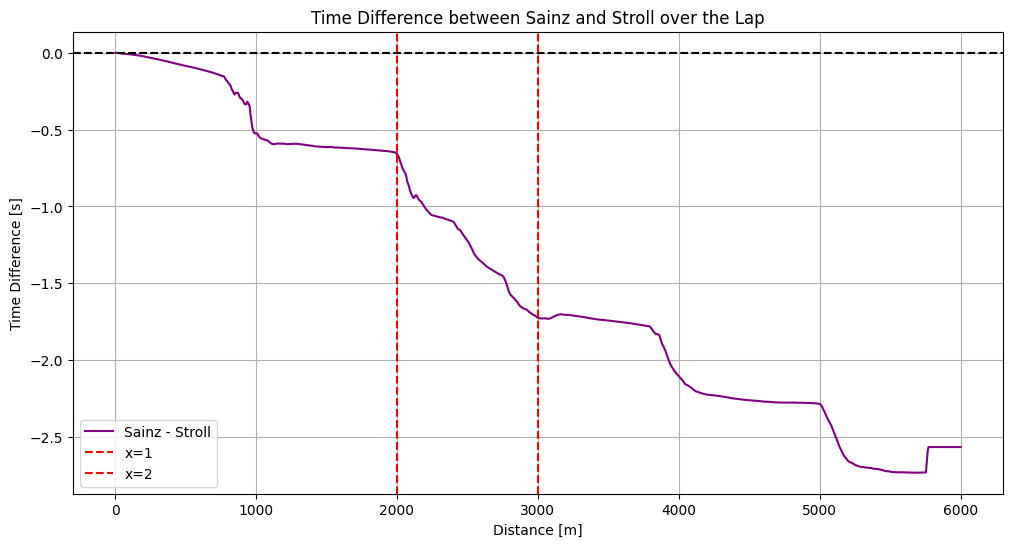

In [76]:
distance_common = np.linspace(0, 6000, 1000)

time_SAI_interp = np.interp(distance_common, tel_SAI['Distance'], tel_SAI['Time'].dt.total_seconds())
time_STR_interp = np.interp(distance_common, tel_STR['Distance'], tel_STR['Time'].dt.total_seconds())

delta_time = time_SAI_interp - time_STR_interp
plt.figure(figsize=(12, 6))
plt.plot(distance_common, delta_time, label='Sainz - Stroll', color='purple')
plt.axhline(0, color='black', linestyle='--')
plt.axvline(x=2000, color='red', linestyle='--', linewidth=1.5, label='x=1')
plt.axvline(x=3000, color='red', linestyle='--', linewidth=1.5, label='x=2')
plt.xlabel('Distance [m]')
plt.ylabel('Time Difference [s]')
plt.title('Time Difference between Sainz and Stroll over the Lap')
plt.legend()
plt.grid()
plt.show()

## Lap Time Delta Analysis

### Methodology
Both drivers do not reach the same distance point at the 
same time. To compare them, we create a common distance 
grid using np.linspace, then interpolate each driver's 
time onto this grid using np.interp. This allows us to 
calculate the time delta at every point on the circuit, 
using Sainz's lap as the reference.

### Results
(graphic)
- Final delta : ~2.5s in favour of Sainz

### Interpretation
This delta time analysis is one of the most powerful tools 
available to a race engineer. By identifying precisely where 
time is lost on the circuit, it allows the engineer to focus 
setup changes, driving coaching, and strategy decisions on 
the most impactful areas — rather than making blind 
adjustments. In this case, the priority zones for Stroll 
would be corner entries between 700m and 3000m.

Stroll loses time in every corner throughout the lap, 
accumulating a total deficit of ~2.5s. The most 
significant time loss occurs between 2000m and 3000m 
(Lesmo 1 & 2), where cornering speed is critical.
This is confirmed by the speed overlay, where Sainz 
consistently carries more speed through these corners.

⚠️ Note: Part of this time loss is attributable to the 
tyre compound difference (Sainz on Softs, Stroll on Hards), 
which directly affects cornering grip and speed.

In [77]:
full_throttle_SAI = tel_SAI[tel_SAI['Throttle'] >= 95]
full_throttle_STR = tel_STR[tel_STR['Throttle'] >= 95]

delta_t_SAI = full_throttle_SAI['Time'].diff()
delta_t_clean = delta_t_SAI[delta_t_SAI < pd.Timedelta('0.5s')]
temps_full_throttle_SAI = delta_t_clean.sum()

delta_t_STR = full_throttle_STR['Time'].diff()
delta_t_clean_STR = delta_t_STR[delta_t_STR < pd.Timedelta('0.5s')]
temps_full_throttle_STR = delta_t_clean_STR.sum()

SAI_full_throttle_percent = (temps_full_throttle_SAI / full_throttle_SAI['Time'].max()) * 100
STR_full_throttle_percent = (temps_full_throttle_STR / full_throttle_STR['Time'].max()) * 100

corners_SAI = tel_SAI[tel_SAI['Speed'] < 150]
corners_STR = tel_STR[tel_STR['Speed'] < 150]

min_speed_SAI = corners_SAI['Speed'].mean()
min_speed_STR = corners_STR['Speed'].mean()


print(f"Full throttle time for Sainz : {temps_full_throttle_SAI}")
print(f"Full throttle time for Stroll : {temps_full_throttle_STR}")
print(f"Percentage of time in full throttle for Sainz : {SAI_full_throttle_percent:.2f}%")
print(f"Percentage of time in full throttle for Stroll : {STR_full_throttle_percent:.2f}%")
print(f"Average speed in corners for Sainz : {min_speed_SAI:.2f} km/h")
print(f"Average speed in corners for Stroll : {min_speed_STR:.2f} km/h")

Full throttle time for Sainz : 0 days 00:00:57.839000
Full throttle time for Stroll : 0 days 00:00:57.780000
Percentage of time in full throttle for Sainz : 72.03%
Percentage of time in full throttle for Stroll : 69.73%
Average speed in corners for Sainz : 108.36 km/h
Average speed in corners for Stroll : 105.49 km/h


## Throttle & Corner Speed Analysis

### Results
| Metric | Sainz | Stroll |
|--------|-------|--------|
| Full throttle time | 57.839s | 57.780s |
| Full throttle % | 72.03% | 69.73% |
| Avg corner speed | 108.36 km/h | 105.49 km/h |

### Interpretation
As we know, Monza is a very rapid track, being at full 
throttle is key to performance. Despite similar full 
throttle times (difference of only 0.059s), Sainz achieves 
a 2.3 percentage point advantage in full throttle %, 
explained by his shorter lap time rather than more time 
at full throttle.
The real performance differentiator is Sainz's average 
corner speed, 2.87 km/h higher than Stroll's. This 
directly translates into better exit speed onto Monza's 
long straights, confirming Segers' analysis (p.357) that 
corner entry speed is the primary performance factor 
between drivers.

⚠️ Note: Sainz used Soft tyres while Stroll used Hard 
tyres during this qualifying session. This compound 
difference partially explains the corner speed gap and 
should be considered when interpreting these results. 
A fairer comparison would require identical tyre compounds.

## Combined G Analysis — Variante del Rettifilo

### Methodology
We use the G_combined method to analyse the tyre grip usage of each driver's car. This method should help us understand if both of them use their car to their limits. We focus on Variante del Rettifilo, the first and one of the most important corners of this track. Indeed, this corner takes place after the main straight and before 476 metres to the next turn. That is why it is a strategic point of the track.


In [78]:
# Stroll

a_lat_list_STR = []
a_long_list_STR = []    

speed_ms_STR = tel_STR['Speed'].values / 3.6
time_s_STR   = tel_STR['Time'].dt.total_seconds().values
a_long_STR   = np.gradient(speed_ms_STR, time_s_STR)

for i in range(1, len(tel_STR)-1):
   
    x = tel_STR['X'].iloc[i-1:i+2].values
    y = tel_STR['Y'].iloc[i-1:i+2].values
  
    r = radius(x[0], y[0], x[1], y[1], x[2], y[2])

    cross = (x[1]-x[0])*(y[2]-y[1]) - (y[1]-y[0])*(x[2]-x[1])


    sign = 1 if cross > 0 else -1
    a_lat = sign * ((tel_STR['Speed'].iloc[i]/3.6) ** 2) / r if r != 0 else 0
    

    a_lat_list_STR.append(a_lat)
    a_long_list_STR.append(a_long_STR[i])


a_long_STR_clean = np.clip(a_long_list_STR, -80, 20)
a_lat_STR_clean = np.clip(a_lat_list_STR, -80, 20)

G_combined_STR = np.sqrt(np.array(a_lat_STR_clean)**2 + np.array(a_long_STR_clean)**2)

dist_STR = tel_STR['Distance'].iloc[1:-1].values

# Sainz

a_lat_list_SAI = []
a_long_list_SAI = []    

speed_ms_SAI = tel_SAI['Speed'].values / 3.6
time_s_SAI   = tel_SAI['Time'].dt.total_seconds().values
a_long_SAI   = np.gradient(speed_ms_SAI, time_s_SAI)

for i in range(1, len(tel_SAI)-1):
   
    x = tel_SAI['X'].iloc[i-1:i+2].values
    y = tel_SAI['Y'].iloc[i-1:i+2].values
  
    r = radius(x[0], y[0], x[1], y[1], x[2], y[2])

    cross = (x[1]-x[0])*(y[2]-y[1]) - (y[1]-y[0])*(x[2]-x[1])


    sign = 1 if cross > 0 else -1
    a_lat = sign * ((tel_SAI['Speed'].iloc[i]/3.6) ** 2) / r if r != 0 else 0
    

    a_lat_list_SAI.append(a_lat)
    a_long_list_SAI.append(a_long_SAI[i])


a_long_SAI_clean = np.clip(a_long_list_SAI, -80, 20)
a_lat_SAI_clean = np.clip(a_lat_list_SAI, -80, 20)

G_combined_SAI = np.sqrt(np.array(a_lat_SAI_clean)**2 + np.array(a_long_SAI_clean)**2)

dist_SAI = tel_SAI['Distance'].iloc[1:-1].values



### Results

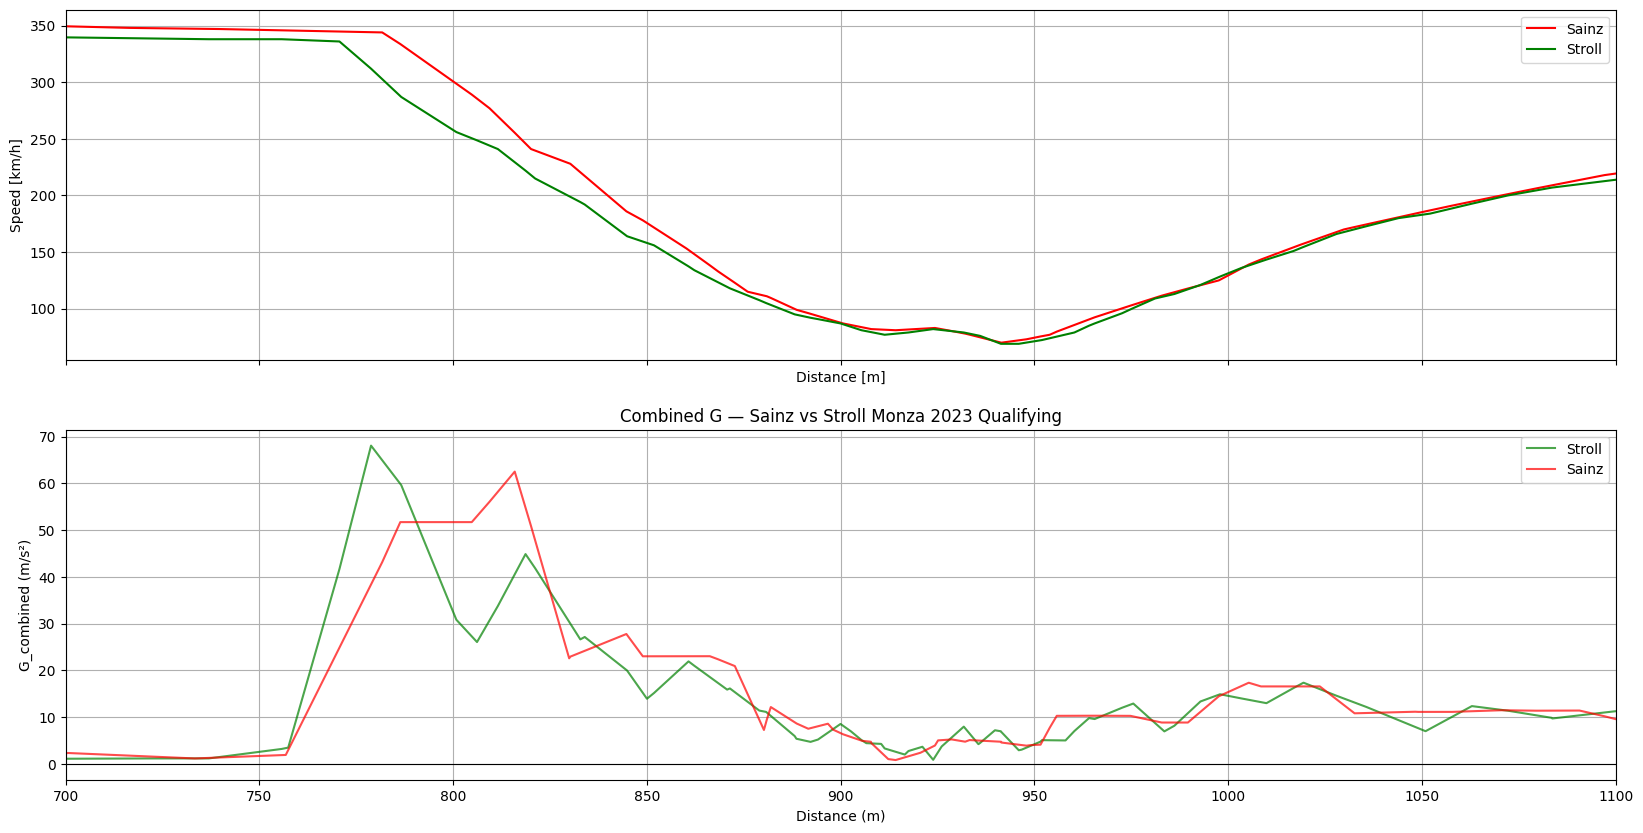

In [79]:
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(20, 10))

axs[0].plot(tel_SAI['Distance'], tel_SAI['Speed'], label='Sainz', color='red')
axs[0].plot(tel_STR['Distance'], tel_STR['Speed'], label='Stroll', color='green')
axs[1].set_xlim(700, 1100)
axs[0].set_ylabel('Speed [km/h]')
axs[0].set_xlabel('Distance [m]')
axs[0].grid()
axs[0].legend()


axs[1].plot(dist_STR, G_combined_STR, color='green', label='Stroll', alpha=0.7)
axs[1].plot(dist_SAI, G_combined_SAI, color='red', label='Sainz', alpha=0.7)
axs[1].axhline(0, color='black', linewidth=0.8)
axs[1].set_xlim(700, 1100)
axs[1].set_title('Combined G — Sainz vs Stroll Monza 2023 Qualifying')
axs[1].set_xlabel('Distance (m)')
axs[1].set_ylabel('G_combined (m/s²)')
axs[1].grid()
axs[1].legend()
plt.show()

- STR G_combined peaks at ~70 m/s² then drops to ~27 m/s², 
  showing a clear valley at 800m
- SAI G_combined maintains a smoother profile peaking at ~52 m/s²

### Interpretation

Despite the tyre compound difference (Soft vs Hard), 
Stroll's G_combined valley at 800m reveals a braking 
technique issue independent of tyre performance — 
a driver who maximises his tyres would show a smooth 
G_combined regardless of compound.

We can see that Stroll's G_combined line (in green) does not 
decrease smoothly and linearly. Near 800 metres, the decrease 
stops and increases again. This suggests that Stroll does not 
use 100% of the tyre's capability — the valley in the combined 
G trace tells us that the car could have handled more lateral 
load at that point (Segers, p.106).
In contrast, Sainz maintains a more consistent G_combined 
throughout the corner entry, suggesting better tyre grip usage.

### Limitations
The absolute values (~70 m/s²) are physically unrealistic for 
an F1 car — real G_combined values should be around 15-20 m/s². 
This overestimation is caused by GPS noise amplified through 
our a_lat calculation (v²/r method). However, the **shape** 
of both curves remains valid for comparative analysis — the 
valley in Stroll's trace is a real indicator of early braking, 
regardless of the absolute values.
Real teams use direct accelerometers to obtain precise values.